# **Day 25: Regression Metrics and Diagnostics**
*Module 4 - Regression*

"R^2 = 0.92" alone tells a reviewer almost nothing. Which metric, on which data, with what uncertainty, compared to which baseline, and where does the model fail? Today we build a complete, publication-grade regression evaluation.

> A single R² number is not enough. RMSE, MAE and bias tell us the size and direction of errors, and residual plots show whether the model makes systematic mistakes, for example under-predicting large values.
>
> *Example:* A biomass model with R² = 0.8 may still under-predict every forest above 200 Mg/ha. A residual plot shows this immediately.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score,
                             mean_absolute_percentage_error, median_absolute_error, max_error)
rng = np.random.default_rng(25)

## **1. The Metric Zoo**

| Metric | Formula | Units | Notes |
|---|---|---|---|
| MAE | $\frac1n\sum\lvert y-\hat y\rvert$ | y | Robust, intuitive ("typical error") |
| MSE | $\frac1n\sum(y-\hat y)^2$ | y^2 | Penalises big errors; what OLS minimises |
| **RMSE** | $\sqrt{\text{MSE}}$ | y | Most reported; sensitive to outliers |
| rRMSE / nRMSE | RMSE / mean(y) | % | Compare across sites/crops |
| **Bias** (ME) | $\frac1n\sum(\hat y-y)$ | y | Systematic over/under-estimation |
| **R^2** | $1-\frac{\sum(y-\hat y)^2}{\sum(y-\bar y)^2}$ | - | Skill vs predicting the mean; can be **negative** |
| MAPE | $\frac1n\sum\lvert\frac{y-\hat y}{y}\rvert$ | % | Explodes when $y\approx 0$ |
| CCC | agreement with the 1:1 line | - | Penalises bias and scale errors |

In [2]:
def ccc(y, yhat):
    """Lin's concordance correlation coefficient."""
    my, mp = y.mean(), yhat.mean(); vy, vp = y.var(), yhat.var(); cov = np.mean((y - my) * (yhat - mp))
    return 2 * cov / (vy + vp + (my - mp) ** 2)

def pearson_r(y, yhat):
    return np.corrcoef(y, yhat)[0, 1] if np.std(yhat) > 0 else 0.0     # a constant prediction has no correlation

def regression_report(y, yhat, name="model"):
    rmse = root_mean_squared_error(y, yhat)
    return {"model": name, "R2": r2_score(y, yhat), "RMSE": rmse, "MAE": mean_absolute_error(y, yhat),
            "Bias": np.mean(yhat - y), "rRMSE_%": 100 * rmse / np.mean(y), "MAPE_%": 100 * mean_absolute_percentage_error(y, yhat),
            "Pearson_r": pearson_r(y, yhat), "CCC": ccc(y, yhat)}

y = rng.gamma(4, 30, 400)                                     # e.g. above-ground biomass (t/ha)
preds = {"good": y + rng.normal(0, 12, 400),
         "biased (+20)": y + 20 + rng.normal(0, 12, 400),
         "compressed (regression to mean)": y.mean() + 0.6 * (y - y.mean()) + rng.normal(0, 8, 400),
         "predict the mean": np.full(400, y.mean())}
pd.DataFrame([regression_report(y, p, k) for k, p in preds.items()]).set_index("model").round(3)

,R2,RMSE,MAE,Bias,rRMSE_%,MAPE_%,Pearson_r,CCC
model,,,,,,,,
good,0.959,11.337,8.876,1.016,9.673,10.376,0.980,0.980
biased (+20),0.816,24.000,20.757,20.189,20.476,23.513,0.974,0.916
compressed (regression to mean),0.814,24.166,18.944,-0.047,20.617,24.017,0.970,0.865
predict the mean,0.000,56.018,43.724,-0.000,47.792,56.086,0.000,0.000


- The **biased** and **compressed** models have high Pearson r, but CCC and bias reveal the problem. **Never report r alone.**
- Predicting the mean gives R^2 = 0 exactly; worse models give negative R^2.

## **2. The Standard Figure: Observed vs Predicted**

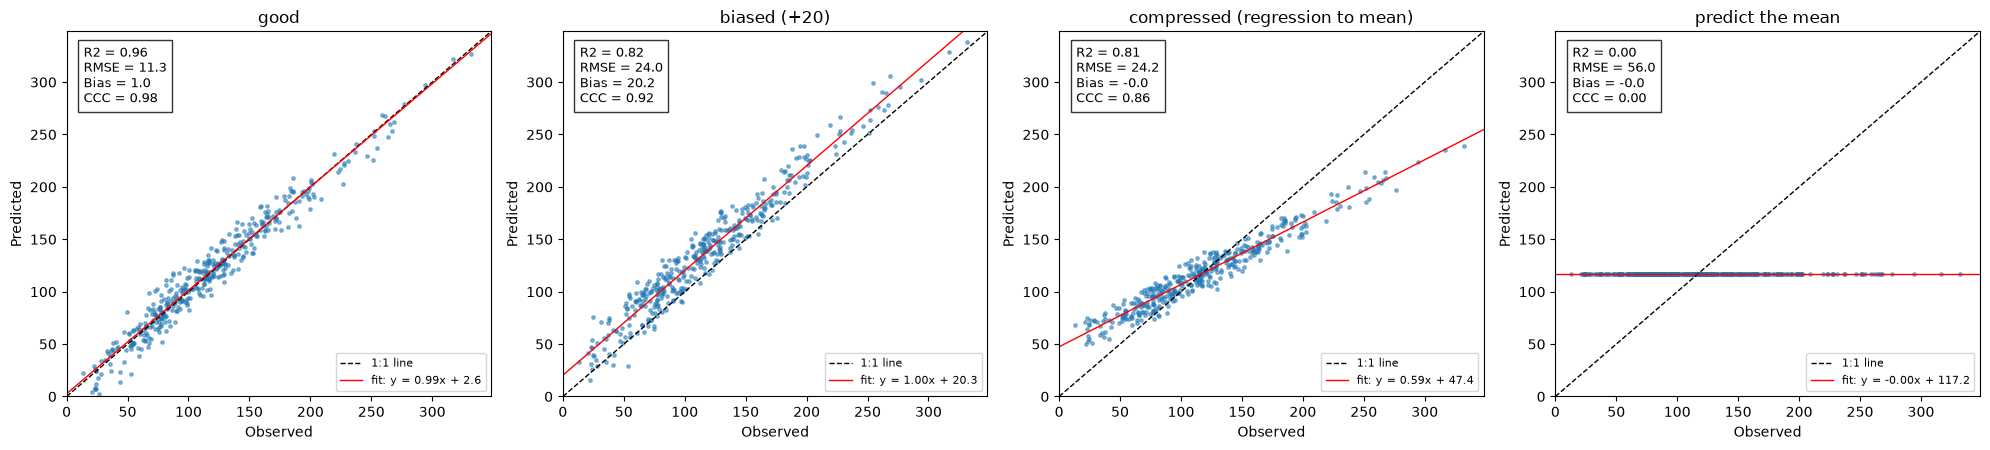

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
lim = [0, y.max() * 1.05]
for ax, (k, p) in zip(axes, preds.items()):
    ax.scatter(y, p, s=6, alpha=0.5)
    ax.plot(lim, lim, "k--", lw=1, label="1:1 line")
    slope, icpt = np.polyfit(y, p, 1)
    ax.plot(lim, icpt + slope * np.array(lim), "r", lw=1, label=f"fit: y = {slope:.2f}x + {icpt:.1f}")
    r = regression_report(y, p)
    ax.text(0.04, 0.96, f"R2 = {r['R2']:.2f}\nRMSE = {r['RMSE']:.1f}\nBias = {r['Bias']:.1f}\nCCC = {r['CCC']:.2f}",
            transform=ax.transAxes, va="top", fontsize=9, bbox=dict(fc="w", alpha=0.8))
    ax.set(xlim=lim, ylim=lim, xlabel="Observed", ylabel="Predicted", title=k); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

**Axis convention:** Pineiro et al. (2008) recommend regressing **observed (y-axis) on predicted (x-axis)** when we test the slope and intercept of the fitted line. Many papers show the reverse, as here. Whichever we choose, state it in the caption and always draw the 1:1 line.

## **3. MSE Decomposition: Systematic vs Random Error**
$$\text{MSE} = \underbrace{(\bar{\hat y}-\bar y)^2}_{\text{bias}^2} + \underbrace{(s_{\hat y} - r\,s_y)^2}_{\text{slope/scale error}} + \underbrace{(1-r^2)\,s_y^2}_{\text{random (unexplained)}}$$
Systematic errors can often be fixed (recalibration, more features); random error cannot.

In [4]:
def mse_decomposition(y, p):
    r = pearson_r(y, p); sy, sp = y.std(), p.std()
    return {"bias^2": (p.mean() - y.mean()) ** 2, "scale": (sp - r * sy) ** 2, "random": (1 - r ** 2) * sy ** 2, "MSE": np.mean((y - p) ** 2)}
pd.DataFrame({k: mse_decomposition(y, p) for k, p in preds.items()}).T.round(1)

,bias^2,scale,random,MSE
good,1.0,2.2,125.3,128.5
biased (+20),407.6,8.4,160.0,576.0
compressed (regression to mean),0.0,400.1,183.9,584.0
predict the mean,0.0,0.0,3138.0,3138.0


## **4. Residual Diagnostics for Any Model**
Plot residuals against predictions and against each feature. Patterns show what the model is missing.

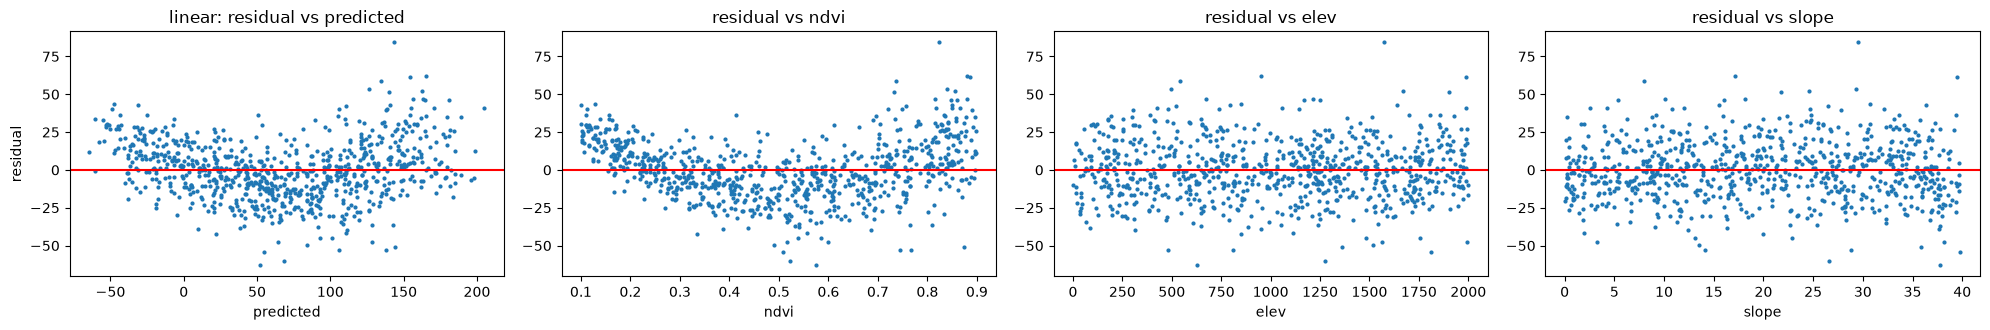

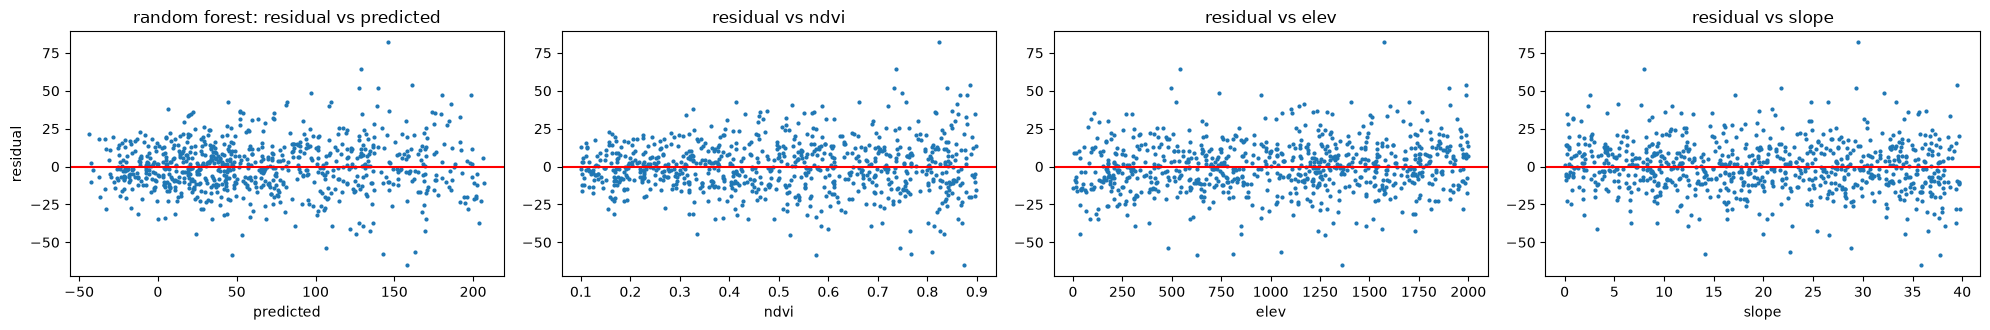

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict
n = 800
X = pd.DataFrame({"ndvi": rng.uniform(0.1, 0.9, n), "elev": rng.uniform(0, 2000, n), "slope": rng.uniform(0, 40, n)})
biomass = 250 * X.ndvi ** 2 + 0.02 * X.elev - 1.5 * X.slope + rng.normal(0, 15, n) * (0.5 + X.ndvi)
for name, m in [("linear", LinearRegression()), ("random forest", RandomForestRegressor(300, min_samples_leaf=3, random_state=0, n_jobs=-1))]:
    pred = cross_val_predict(m, X, biomass, cv=5)
    res = biomass - pred
    fig, axes = plt.subplots(1, 4, figsize=(20, 3.4))
    axes[0].scatter(pred, res, s=4); axes[0].set(xlabel="predicted", ylabel="residual", title=f"{name}: residual vs predicted")
    for ax, f in zip(axes[1:], X.columns):
        ax.scatter(X[f], res, s=4); ax.set(xlabel=f, title=f"residual vs {f}")
    for ax in axes: ax.axhline(0, c="r")
    plt.tight_layout(); plt.show()

The linear model's residuals curve against NDVI (a missing $\text{NDVI}^2$ term). Both models show residual spread increasing with NDVI (heteroscedastic noise): uncertainty should be reported per prediction (Day 77).

## **5. Confidence Intervals for Metrics (Bootstrap)**

In [6]:
def bootstrap_metrics(y, p, B=2000, seed=0):
    r = np.random.default_rng(seed); n_ = len(y); out = []
    for _ in range(B):
        i = r.integers(0, n_, n_); out.append([r2_score(y[i], p[i]), root_mean_squared_error(y[i], p[i]), np.mean(p[i] - y[i])])
    out = np.array(out)
    return pd.DataFrame({"estimate": [r2_score(y, p), root_mean_squared_error(y, p), np.mean(p - y)],
                         "CI_2.5%": np.percentile(out, 2.5, 0), "CI_97.5%": np.percentile(out, 97.5, 0)}, index=["R2", "RMSE", "Bias"])
pred_rf = cross_val_predict(RandomForestRegressor(300, min_samples_leaf=3, random_state=0, n_jobs=-1), X, biomass, cv=5)
bootstrap_metrics(biomass.values, pred_rf).round(3)

,estimate,CI_2.5%,CI_97.5%
R2,0.932,0.922,0.941
RMSE,17.065,15.973,18.227
Bias,0.023,-1.223,1.219


**Reporting template:** "The RF model achieved R^2 = 0.87 (95% CI 0.85-0.89) and RMSE = 21.3 t/ha (rRMSE = 18%) in 5-fold cross-validation (n = 800)."

# **Part 2: Going Deeper**

### Regression to the mean: why ML predictions are "compressed"
Any model minimising MSE predicts the **conditional mean**, which is less variable than the data: high values are underestimated and low values overestimated (slope < 1 in the observed-vs-predicted fit). This is not a bug, but it matters for mapping extremes (e.g. highest-biomass forests). Do **not** "fix" it by regressing observed on predicted and inverting without care: that increases MSE.

In [7]:
slope = np.polyfit(biomass, pred_rf, 1)[0]
q = pd.qcut(biomass, 5, labels=["lowest 20%", "2", "3", "4", "highest 20%"])
print(f"Slope of predicted on observed: {slope:.2f} (1.0 = no compression)")
print(pd.DataFrame({"obs": biomass, "bias": pred_rf - biomass}).groupby(q, observed=True).bias.mean().round(1))

Slope of predicted on observed: 0.93 (1.0 = no compression)
lowest 20%     6.4
2              1.9
3             -0.5
4             -0.7
highest 20%   -7.0
Name: bias, dtype: float64


### Bland-Altman plot (agreement between two measurement methods)
Plot the **difference** against the **mean** of the two methods, with limits of agreement $\bar d \pm 1.96 s_d$. Common for comparing satellite estimates with field measurements.

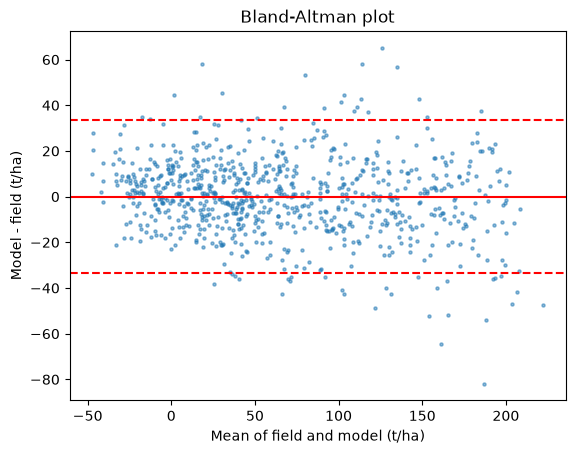

In [8]:
mean_ = (biomass + pred_rf) / 2; diff = pred_rf - biomass
plt.scatter(mean_, diff, s=5, alpha=0.5)
for v, ls in [(diff.mean(), "-"), (diff.mean() + 1.96 * diff.std(), "--"), (diff.mean() - 1.96 * diff.std(), "--")]:
    plt.axhline(v, c="r", ls=ls)
plt.xlabel("Mean of field and model (t/ha)"); plt.ylabel("Model - field (t/ha)"); plt.title("Bland-Altman plot"); plt.show()

### Skill scores: how much better than a baseline?
$\text{Skill} = 1 - \frac{\text{MSE}_{model}}{\text{MSE}_{baseline}}$. With the mean as baseline this is R^2. Use **domain baselines** too: persistence (yesterday's value), climatology, an NDVI-only regression.

In [9]:
base_pred = cross_val_predict(LinearRegression(), X[["ndvi"]], biomass, cv=5)
print(f"Skill of RF over the NDVI-only baseline: {1 - mean_squared_error(biomass, pred_rf) / mean_squared_error(biomass, base_pred):.3f}")

Skill of RF over the NDVI-only baseline: 0.644


## **Practice Problems**
1. Why is MAPE dangerous for a target like "change in forest cover" that can be zero or negative?
2. Compute the RMSE and MAE of the `predict the mean` model. Which is larger and why is RMSE >= MAE always?
3. Add 5 huge errors (+500) to the `good` predictions. How do RMSE, MAE and median absolute error change?
4. *(Advanced)* Fit a linear model with `ndvi**2` added. Does the curvature disappear from the residual plot? Report its bootstrap CI for R^2.

mean model: RMSE 56.0 MAE 43.7 -> RMSE >= MAE (Jensen's inequality)
good             RMSE   11.3  MAE    8.9  MedAE    7.1
with 5 outliers  RMSE   57.3  MAE   15.1  MedAE    7.3


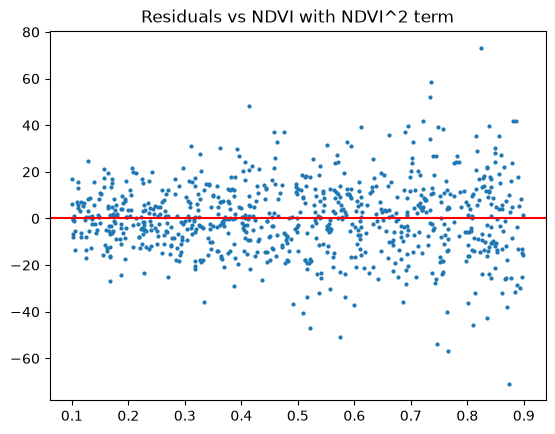

{'estimate': 0.943, 'CI_2.5%': 0.934, 'CI_97.5%': 0.95}


In [10]:
# Solution 2-3
print("mean model: RMSE", round(root_mean_squared_error(y, preds["predict the mean"]), 1), "MAE", round(mean_absolute_error(y, preds["predict the mean"]), 1),
      "-> RMSE >= MAE (Jensen's inequality)")
bad = preds["good"].copy(); bad[:5] += 500
for nm, p in [("good", preds["good"]), ("with 5 outliers", bad)]:
    print(f"{nm:<16} RMSE {root_mean_squared_error(y, p):6.1f}  MAE {mean_absolute_error(y, p):6.1f}  MedAE {median_absolute_error(y, p):6.1f}")
# Solution 4
X2 = X.assign(ndvi2=X.ndvi ** 2)
p2 = cross_val_predict(LinearRegression(), X2, biomass, cv=5)
plt.scatter(X.ndvi, biomass - p2, s=4); plt.axhline(0, c="r"); plt.title("Residuals vs NDVI with NDVI^2 term"); plt.show()
print(bootstrap_metrics(biomass.values, p2).round(3).loc["R2"].to_dict())

**Solution 1:** MAPE divides by $y$; near zero it explodes and with negative values it is meaningless. Use MAE/RMSE or a symmetric metric.

## **Key References**
- Pineiro, G., Perelman, S., Guerschman, J. P., & Paruelo, J. M. (2008). How to evaluate models: Observed vs. predicted or predicted vs. observed? *Ecological Modelling*, 216(3-4), 316-322.
- Lin, L. I.-K. (1989). A concordance correlation coefficient to evaluate reproducibility. *Biometrics*, 45(1), 255-268.
- Willmott, C. J., & Matsuura, K. (2005). Advantages of the mean absolute error (MAE) over the root mean square error (RMSE) in assessing average model performance. *Climate Research*, 30(1), 79-82.
- Bland, J. M., & Altman, D. G. (1986). Statistical methods for assessing agreement between two methods of clinical measurement. *The Lancet*, 327(8476), 307-310.
- Chai, T., & Draxler, R. R. (2014). Root mean square error (RMSE) or mean absolute error (MAE)? *Geoscientific Model Development*, 7(3), 1247-1250.